# E-commerce Sentiment — Experiment 1

Baseline: 2,000 most frequent TF-IDF terms; MLP 128-64.


In [1]:
EXPERIMENT_NAME = "exp1"
EXPERIMENT_DESCRIPTION = 'Baseline: 2,000 most frequent TF-IDF terms; MLP 128-64.'
print(EXPERIMENT_NAME, EXPERIMENT_DESCRIPTION)


exp1 Baseline: 2,000 most frequent TF-IDF terms; MLP 128-64.


In [2]:
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from collections import Counter

SEED = 42
np.random.seed(SEED)

DATA_PATH = Path(
    "data/Womens Clothing E-Commerce Reviews.csv"
)

MODEL_DIR = Path("models")
FIGURE_DIR = Path("figures")
OUTPUT_DIR = Path("outputs")

MODEL_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

In [3]:
df = pd.read_csv(DATA_PATH)

print(df.shape)
print(df.columns.tolist())

display(df.head())

print("\nMissing values:")
print(df.isna().sum())

(23486, 11)
['Unnamed: 0', 'Clothing ID', 'Age', 'Title', 'Review Text', 'Rating', 'Recommended IND', 'Positive Feedback Count', 'Division Name', 'Department Name', 'Class Name']


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses



Missing values:
Unnamed: 0                    0
Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64


In [4]:
def rating_to_sentiment(rating):

    if rating <= 2:
        return 0

    elif rating == 3:
        return 1

    else:
        return 2

df = df.dropna(
    subset=["Review Text", "Rating"]
).copy()

df["sentiment"] = (
    df["Rating"]
    .apply(rating_to_sentiment)
)

print(
    df["sentiment"].value_counts()
)

print(
    df["sentiment"].value_counts(
        normalize=True
    )
)

class_names = np.array(
    [
        "Negative",
        "Neutral",
        "Positive"
    ],
    dtype=str
)

sentiment
2    17448
1     2823
0     2370
Name: count, dtype: int64
sentiment
2    0.770637
1    0.124685
0    0.104677
Name: proportion, dtype: float64


In [5]:
texts = (
    df["Review Text"]
    .astype(str)
    .to_numpy()
)

y = (
    df["sentiment"]
    .to_numpy(dtype=np.int64)
)

print(texts.shape)
print(y.shape)

(22641,)
(22641,)


In [6]:
def stratified_split_indices(
    y,
    train_ratio=0.70,
    val_ratio=0.15,
    seed=42
):

    rng = np.random.default_rng(seed)

    train_idx = []
    val_idx = []
    test_idx = []

    for cls in np.unique(y):

        idx = np.where(
            y == cls
        )[0]

        rng.shuffle(idx)

        n = len(idx)

        n_train = int(
            n * train_ratio
        )

        n_val = int(
            n * val_ratio
        )

        train_idx.extend(
            idx[:n_train]
        )

        val_idx.extend(
            idx[
                n_train:
                n_train + n_val
            ]
        )

        test_idx.extend(
            idx[
                n_train + n_val:
            ]
        )

    train_idx = np.array(train_idx)
    val_idx = np.array(val_idx)
    test_idx = np.array(test_idx)

    rng.shuffle(train_idx)
    rng.shuffle(val_idx)
    rng.shuffle(test_idx)

    return (
        train_idx,
        val_idx,
        test_idx
    )

train_idx, val_idx, test_idx = (
    stratified_split_indices(
        y,
        seed=SEED
    )
)

text_train = texts[train_idx]
text_val = texts[val_idx]
text_test = texts[test_idx]

y_train = y[train_idx]
y_val = y[val_idx]
y_test = y[test_idx]

for name, target in [
    ("Train", y_train),
    ("Validation", y_val),
    ("Test", y_test)
]:

    print(name)

    print(
        np.bincount(
            target,
            minlength=3
        )
    )

Train
[ 1659  1976 12213]
Validation
[ 355  423 2617]
Test
[ 356  424 2618]


In [7]:
def tokenize(text):

    return re.findall(
        r"[a-z']+",
        str(text).lower()
    )

In [8]:
MAX_VOCAB = 2000

word_counts = Counter()

for text in text_train:

    word_counts.update(
        tokenize(text)
    )

most_common = (
    word_counts
    .most_common(MAX_VOCAB)
)

vocab_words = np.array(
    [
        word
        for word, count
        in most_common
    ],
    dtype=str
)

vocab = {
    word: i
    for i, word
    in enumerate(vocab_words)
}

print(
    "Vocabulary size:",
    len(vocab)
)

Vocabulary size: 2000


In [9]:
document_frequency = np.zeros(
    len(vocab),
    dtype=np.float32
)

for text in text_train:

    unique_words = set(
        tokenize(text)
    )

    for word in unique_words:

        idx = vocab.get(word)

        if idx is not None:
            document_frequency[idx] += 1

N = len(text_train)

idf = (
    np.log(
        (N + 1)
        /
        (document_frequency + 1)
    )
    + 1
).astype(np.float32)

In [10]:
def transform_tfidf(
    texts,
    vocab,
    idf
):

    X = np.zeros(
        (
            len(texts),
            len(vocab)
        ),
        dtype=np.float32
    )

    for i, text in enumerate(texts):

        tokens = tokenize(text)

        if len(tokens) == 0:
            continue

        counts = Counter(tokens)

        total = len(tokens)

        for word, count in counts.items():

            idx = vocab.get(word)

            if idx is None:
                continue

            tf = count / total

            X[i, idx] = (
                tf
                *
                idf[idx]
            )

    # L2 normalization
    norm = np.linalg.norm(
        X,
        axis=1,
        keepdims=True
    )

    norm = np.where(
        norm < 1e-8,
        1.0,
        norm
    )

    return X / norm


X_train = transform_tfidf(
    text_train,
    vocab,
    idf
)

X_val = transform_tfidf(
    text_val,
    vocab,
    idf
)

X_test = transform_tfidf(
    text_test,
    vocab,
    idf
)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(15848, 2000)
(3395, 2000)
(3398, 2000)


In [11]:
def relu(x):
    return np.maximum(0, x)


def relu_derivative(x):
    return (x > 0).astype(
        np.float32
    )


def softmax(z):

    z = (
        z
        -
        np.max(
            z,
            axis=1,
            keepdims=True
        )
    )

    exp_z = np.exp(z)

    return (
        exp_z
        /
        np.sum(
            exp_z,
            axis=1,
            keepdims=True
        )
    )

In [12]:
def initialize_parameters(
    input_dim,
    hidden1=128,
    hidden2=64,
    output_dim=3,
    seed=42
):

    rng = np.random.default_rng(seed)

    W1 = (
        rng.standard_normal(
            (input_dim, hidden1)
        )
        *
        np.sqrt(
            2.0 / input_dim
        )
    ).astype(np.float32)

    b1 = np.zeros(
        (1, hidden1),
        dtype=np.float32
    )

    W2 = (
        rng.standard_normal(
            (hidden1, hidden2)
        )
        *
        np.sqrt(
            2.0 / hidden1
        )
    ).astype(np.float32)

    b2 = np.zeros(
        (1, hidden2),
        dtype=np.float32
    )

    W3 = (
        rng.standard_normal(
            (hidden2, output_dim)
        )
        *
        np.sqrt(
            2.0 / hidden2
        )
    ).astype(np.float32)

    b3 = np.zeros(
        (1, output_dim),
        dtype=np.float32
    )

    return {
        "W1": W1,
        "b1": b1,
        "W2": W2,
        "b2": b2,
        "W3": W3,
        "b3": b3
    }

params = initialize_parameters(
    input_dim=X_train.shape[1],
    seed=SEED
)

for name, value in params.items():
    print(name, value.shape)

W1 (2000, 128)
b1 (1, 128)
W2 (128, 64)
b2 (1, 64)
W3 (64, 3)
b3 (1, 3)


In [13]:
def forward(X, params):

    z1 = (
        X @ params["W1"]
        + params["b1"]
    )

    h1 = relu(z1)

    z2 = (
        h1 @ params["W2"]
        + params["b2"]
    )

    h2 = relu(z2)

    z3 = (
        h2 @ params["W3"]
        + params["b3"]
    )

    probs = softmax(z3)

    cache = {
        "X": X,
        "z1": z1,
        "h1": h1,
        "z2": z2,
        "h2": h2,
        "z3": z3,
        "probs": probs
    }

    return probs, cache

In [14]:
def cross_entropy_loss(
    probs,
    y
):

    eps = 1e-12

    n = len(y)

    correct_prob = probs[
        np.arange(n),
        y
    ]

    return -np.mean(
        np.log(
            correct_prob + eps
        )
    )

In [15]:
def backward(
    y,
    params,
    cache
):

    X = cache["X"]
    z1 = cache["z1"]
    h1 = cache["h1"]

    z2 = cache["z2"]
    h2 = cache["h2"]

    probs = cache["probs"]

    n = len(y)

    dz3 = probs.copy()

    dz3[
        np.arange(n),
        y
    ] -= 1

    dz3 /= n

    dW3 = h2.T @ dz3

    db3 = np.sum(
        dz3,
        axis=0,
        keepdims=True
    )

    dh2 = (
        dz3
        @
        params["W3"].T
    )

    dz2 = (
        dh2
        *
        relu_derivative(z2)
    )

    dW2 = h1.T @ dz2

    db2 = np.sum(
        dz2,
        axis=0,
        keepdims=True
    )

    dh1 = (
        dz2
        @
        params["W2"].T
    )

    dz1 = (
        dh1
        *
        relu_derivative(z1)
    )

    dW1 = X.T @ dz1

    db1 = np.sum(
        dz1,
        axis=0,
        keepdims=True
    )

    return {
        "W1": dW1,
        "b1": db1,
        "W2": dW2,
        "b2": db2,
        "W3": dW3,
        "b3": db3
    }

In [16]:
def update_parameters(
    params,
    grads,
    learning_rate
):

    for key in params:

        params[key] -= (
            learning_rate
            *
            grads[key]
        )

In [17]:
learning_rate = 0.01
epochs = 25
batch_size = 256

rng = np.random.default_rng(SEED)

train_loss_history = []
val_loss_history = []

for epoch in range(epochs):

    indices = rng.permutation(
        len(X_train)
    )

    for start in range(
        0,
        len(X_train),
        batch_size
    ):

        batch_idx = indices[
            start:
            start + batch_size
        ]

        X_batch = X_train[
            batch_idx
        ]

        y_batch = y_train[
            batch_idx
        ]

        probs, cache = forward(
            X_batch,
            params
        )

        grads = backward(
            y_batch,
            params,
            cache
        )

        update_parameters(
            params,
            grads,
            learning_rate
        )

    train_probs, _ = forward(
        X_train,
        params
    )

    val_probs, _ = forward(
        X_val,
        params
    )

    train_loss = cross_entropy_loss(
        train_probs,
        y_train
    )

    val_loss = cross_entropy_loss(
        val_probs,
        y_val
    )

    train_loss_history.append(
        train_loss
    )

    val_loss_history.append(
        val_loss
    )

    print(
        f"Epoch {epoch+1:02d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

Epoch 01 | Train Loss: 0.7711 | Val Loss: 0.7705
Epoch 02 | Train Loss: 0.7065 | Val Loss: 0.7057
Epoch 03 | Train Loss: 0.6971 | Val Loss: 0.6962
Epoch 04 | Train Loss: 0.6950 | Val Loss: 0.6942
Epoch 05 | Train Loss: 0.6937 | Val Loss: 0.6929
Epoch 06 | Train Loss: 0.6926 | Val Loss: 0.6918
Epoch 07 | Train Loss: 0.6915 | Val Loss: 0.6907
Epoch 08 | Train Loss: 0.6903 | Val Loss: 0.6896
Epoch 09 | Train Loss: 0.6892 | Val Loss: 0.6885
Epoch 10 | Train Loss: 0.6880 | Val Loss: 0.6873
Epoch 11 | Train Loss: 0.6868 | Val Loss: 0.6861
Epoch 12 | Train Loss: 0.6855 | Val Loss: 0.6849
Epoch 13 | Train Loss: 0.6842 | Val Loss: 0.6836
Epoch 14 | Train Loss: 0.6828 | Val Loss: 0.6822
Epoch 15 | Train Loss: 0.6814 | Val Loss: 0.6808
Epoch 16 | Train Loss: 0.6798 | Val Loss: 0.6793
Epoch 17 | Train Loss: 0.6782 | Val Loss: 0.6777
Epoch 18 | Train Loss: 0.6765 | Val Loss: 0.6760
Epoch 19 | Train Loss: 0.6748 | Val Loss: 0.6743
Epoch 20 | Train Loss: 0.6730 | Val Loss: 0.6725
Epoch 21 | Train Los

In [18]:
test_probs, _ = forward(
    X_test,
    params
)

y_pred = np.argmax(
    test_probs,
    axis=1
)

def confusion_matrix_multiclass(
    y_true,
    y_pred,
    num_classes
):

    cm = np.zeros(
        (
            num_classes,
            num_classes
        ),
        dtype=int
    )

    for true, pred in zip(
        y_true,
        y_pred
    ):

        cm[true, pred] += 1

    return cm


cm = confusion_matrix_multiclass(
    y_test,
    y_pred,
    3
)

print(cm)

accuracy = np.mean(
    y_pred == y_test
)

print(
    f"Accuracy: {accuracy:.4f}"
)

[[   0    0  356]
 [   0    0  424]
 [   0    0 2618]]
Accuracy: 0.7705


In [19]:
ECOMMERCE_MODEL_PATH = (
    MODEL_DIR
    /
    "ecommerce_sentiment_numpy_mlp-exp1.npz"
)

np.savez(
    ECOMMERCE_MODEL_PATH,

    # Neural Network parameters
    W1=params["W1"],
    b1=params["b1"],

    W2=params["W2"],
    b2=params["b2"],

    W3=params["W3"],
    b3=params["b3"],

    # TF-IDF preprocessing
    vocab_words=np.asarray(
        vocab_words,
        dtype=str
    ),

    idf=np.asarray(
        idf,
        dtype=np.float32
    ),

    # Class labels
    class_names=np.asarray(
        class_names,
        dtype=str
    )
)

print(
    "Saved model:",
    ECOMMERCE_MODEL_PATH
)

Saved model: models\ecommerce_sentiment_numpy_mlp-exp1.npz


In [20]:
saved = np.load(
    ECOMMERCE_MODEL_PATH
)

loaded_params = {
    "W1": saved["W1"],
    "b1": saved["b1"],

    "W2": saved["W2"],
    "b2": saved["b2"],

    "W3": saved["W3"],
    "b3": saved["b3"]
}

loaded_vocab_words = saved[
    "vocab_words"
]

loaded_idf = saved[
    "idf"
]

loaded_class_names = saved[
    "class_names"
]

loaded_vocab = {
    word: i
    for i, word
    in enumerate(
        loaded_vocab_words
    )
}

print(
    "E-commerce model loaded successfully."
)

print(
    "W1:",
    loaded_params["W1"].shape
)

print(
    "Vocabulary:",
    len(loaded_vocab_words)
)

print(
    "Classes:",
    loaded_class_names
)

E-commerce model loaded successfully.
W1: (2000, 128)
Vocabulary: 2000
Classes: ['Negative' 'Neutral' 'Positive']


In [21]:
def predict_comment(
    text,
    params,
    vocab,
    idf,
    class_names
):

    X = transform_tfidf(
        [text],
        vocab,
        idf
    )

    probabilities, _ = forward(
        X,
        params
    )

    predicted_class = int(
        np.argmax(
            probabilities[0]
        )
    )

    sentiment = (
        class_names[
            predicted_class
        ]
    )

    return {
        "sentiment": sentiment,
        "probabilities": probabilities[0]
    }

result = predict_comment(
    "I really love this dress. It fits perfectly!",
    loaded_params,
    loaded_vocab,
    loaded_idf,
    loaded_class_names
)

print(result)

{'sentiment': 'Positive', 'probabilities': array([0.09317581, 0.11110805, 0.7957161 ], dtype=float32)}


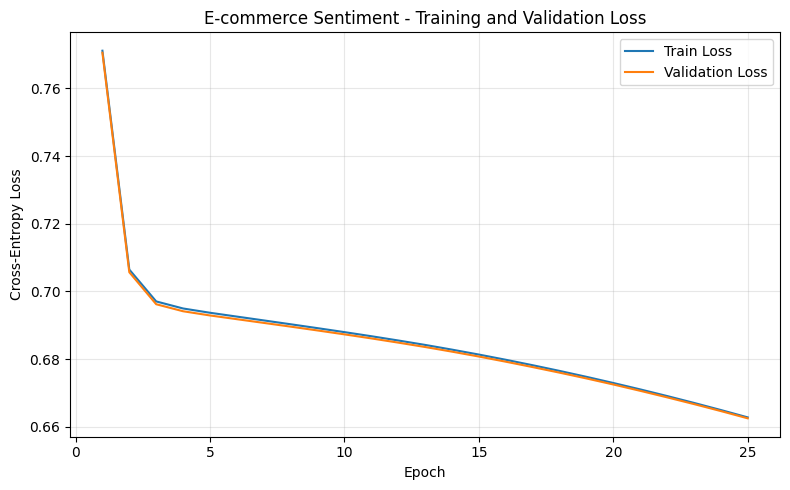

Saved: figures\ecommerce_loss_curve-exp1.png


In [22]:
plt.figure(
    figsize=(8, 5)
)

epochs_axis = np.arange(
    1,
    len(train_loss_history) + 1
)

plt.plot(
    epochs_axis,
    train_loss_history,
    label="Train Loss"
)

plt.plot(
    epochs_axis,
    val_loss_history,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")

plt.title(
    "E-commerce Sentiment - Training and Validation Loss"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

LOSS_FIGURE_PATH = (
    FIGURE_DIR
    /
    "ecommerce_loss_curve-exp1.png"
)

plt.savefig(
    LOSS_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    LOSS_FIGURE_PATH
)

In [23]:
def multiclass_metrics(
    y_true,
    y_pred,
    num_classes
):

    precision_list = []
    recall_list = []
    f1_list = []

    for cls in range(
        num_classes
    ):

        TP = np.sum(
            (y_true == cls)
            &
            (y_pred == cls)
        )

        FP = np.sum(
            (y_true != cls)
            &
            (y_pred == cls)
        )

        FN = np.sum(
            (y_true == cls)
            &
            (y_pred != cls)
        )

        precision = (
            TP / (TP + FP)
            if (TP + FP) > 0
            else 0.0
        )

        recall = (
            TP / (TP + FN)
            if (TP + FN) > 0
            else 0.0
        )

        f1 = (
            2
            * precision
            * recall
            /
            (precision + recall)
            if (precision + recall) > 0
            else 0.0
        )

        precision_list.append(
            precision
        )

        recall_list.append(
            recall
        )

        f1_list.append(
            f1
        )

    return (
        np.array(precision_list),
        np.array(recall_list),
        np.array(f1_list)
    )

test_probs, _ = forward(
    X_test,
    params
)

y_pred = np.argmax(
    test_probs,
    axis=1
)

accuracy = np.mean(
    y_pred == y_test
)

precision, recall, f1 = multiclass_metrics(
    y_test,
    y_pred,
    num_classes=3
)

print(
    f"Accuracy: {accuracy:.4f}"
)

for i, name in enumerate(
    class_names
):

    print(
        f"{name:10s} | "
        f"Precision={precision[i]:.4f} | "
        f"Recall={recall[i]:.4f} | "
        f"F1={f1[i]:.4f}"
    )

print(
    "Macro F1:",
    f"{np.mean(f1):.4f}"
)

Accuracy: 0.7705
Negative   | Precision=0.0000 | Recall=0.0000 | F1=0.0000
Neutral    | Precision=0.0000 | Recall=0.0000 | F1=0.0000
Positive   | Precision=0.7705 | Recall=1.0000 | F1=0.8703
Macro F1: 0.2901


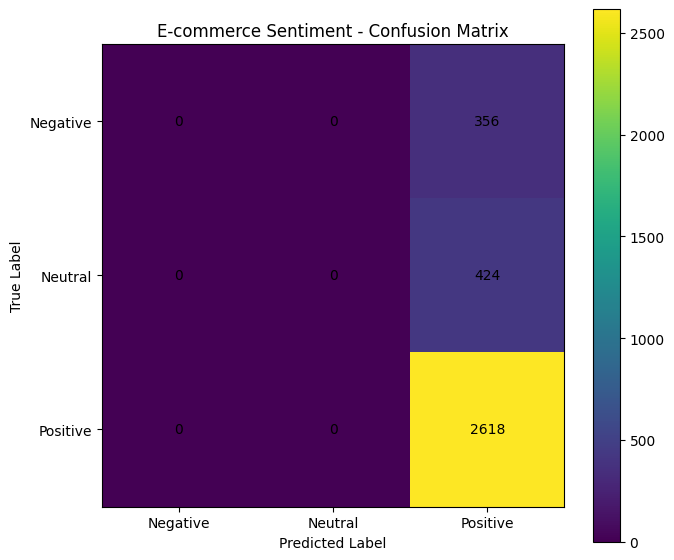

In [24]:
cm = confusion_matrix_multiclass(
    y_test,
    y_pred,
    num_classes=3
)

plt.figure(
    figsize=(7, 6)
)

plt.imshow(cm)

plt.title(
    "E-commerce Sentiment - Confusion Matrix"
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "True Label"
)

plt.xticks(
    np.arange(3),
    class_names
)

plt.yticks(
    np.arange(3),
    class_names
)

for i in range(3):
    for j in range(3):

        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center"
        )

plt.colorbar()

plt.tight_layout()

CM_PATH = (
    FIGURE_DIR
    /
    "ecommerce_confusion_matrix-exp1.png"
)

plt.savefig(
    CM_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()



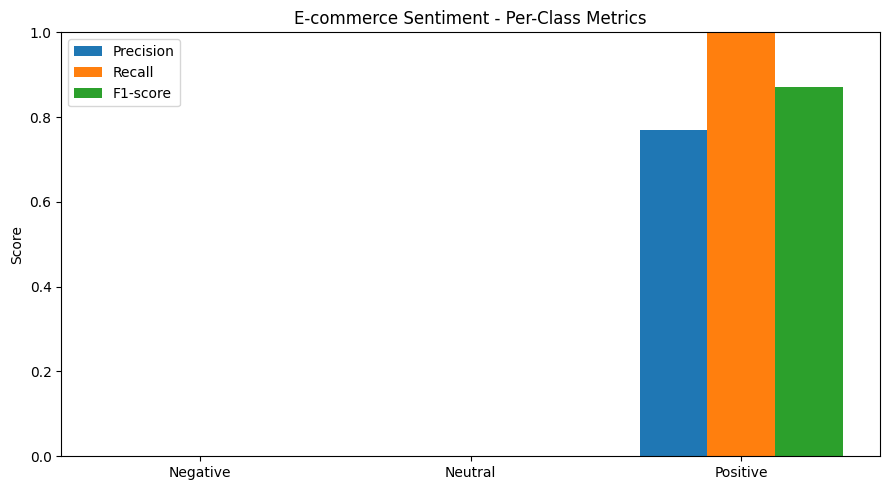

In [25]:
x = np.arange(
    len(class_names)
)

width = 0.25

plt.figure(
    figsize=(9, 5)
)

plt.bar(
    x - width,
    precision,
    width,
    label="Precision"
)

plt.bar(
    x,
    recall,
    width,
    label="Recall"
)

plt.bar(
    x + width,
    f1,
    width,
    label="F1-score"
)

plt.xticks(
    x,
    class_names
)

plt.ylim(
    0,
    1
)

plt.ylabel("Score")

plt.title(
    "E-commerce Sentiment - Per-Class Metrics"
)

plt.legend()

plt.tight_layout()

METRICS_PATH = (
    FIGURE_DIR
    /
    "ecommerce_class_metrics-exp1.png"
)

plt.savefig(
    METRICS_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [26]:
ecommerce_metrics = pd.DataFrame({
    "Class": class_names, "Precision": precision, "Recall": recall, "F1": f1
})
ecommerce_metrics.to_csv(OUTPUT_DIR / "ecommerce_class_metrics-exp1.csv", index=False)
summary_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1"],
    "Value": [accuracy, np.mean(precision), np.mean(recall), np.mean(f1)]
})
summary_metrics.to_csv(OUTPUT_DIR / "ecommerce_summary_metrics-exp1.csv", index=False)
display(ecommerce_metrics); display(summary_metrics)


,Class,Precision,Recall,F1
0,Negative,0.000000,0.0,0.000000
1,Neutral,0.000000,0.0,0.000000
2,Positive,0.770453,1.0,0.870346


,Metric,Value
0,Accuracy,0.770453
1,Macro Precision,0.256818
2,Macro Recall,0.333333
3,Macro F1,0.290115


In [27]:
experiment_config = {
    "experiment": "exp1",
    "description": EXPERIMENT_DESCRIPTION,
    "feature_selection": False,
    "input_features": ["Review Text"],
    "vocabulary_size": int(len(vocab_words)),
    "selected_feature_count": int(X_train.shape[1]),
    "learning_rate": learning_rate,
    "epochs": epochs,
    "batch_size": batch_size,
    "accuracy": float(accuracy),
    "macro_f1": float(np.mean(f1)),
}
with open(OUTPUT_DIR / "ecommerce_config-exp1.json", "w", encoding="utf-8") as f:
    json.dump(experiment_config, f, ensure_ascii=False, indent=2)
print("Saved experiment config:", experiment_config)


Saved experiment config: {'experiment': 'exp1', 'description': 'Baseline: 2,000 most frequent TF-IDF terms; MLP 128-64.', 'feature_selection': False, 'input_features': ['Review Text'], 'vocabulary_size': 2000, 'selected_feature_count': 2000, 'learning_rate': 0.01, 'epochs': 25, 'batch_size': 256, 'accuracy': 0.7704532077692761, 'macro_f1': 0.29011524822695034}
